![a3uAqnb.png](https://i.imgur.com/a3uAqnb.png)

# Parameter-Efficient Fine-Tuning (PEFT)



Parameter-Efficient Fine-Tuning (PEFT) is an approach for adapting a pretrained model to a downstream task while training only a small number of parameters, instead of updating all parameters in the model.

In traditional Full Fine-Tuning, all or most pretrained parameters are updated during training.

In PEFT, most of the pretrained model remains frozen, while only a small set of task-specific parameters is optimized. [*(Ref)*](https://huggingface.co/docs/peft/index)

Conceptually:

$$
\theta_{\text{base}} = \text{frozen pretrained parameters}
$$

$$
\phi = \text{small set of trainable parameters}
$$

where:

$$
|\phi| \ll |\theta_{\text{base}}|
$$



Modern pretrained language models can contain hundreds of millions or billions of parameters.
Updating every parameter for every new task can require substantial:

- GPU memory
- computation
- training time
- model storage

<p align="center">
  <img src="https://towardsdatascience.com/wp-content/uploads/2023/08/0bsEuw4SQkYzs6oAJ.png" width="750">
</p>

<p align="center">
  <em>Source: Towards Data Science</em>
</p>

## 1- Bottleneck Adapters

An **adapter** is a small trainable neural-network module inserted inside a pretrained Transformer while the original pretrained model parameters remain frozen.

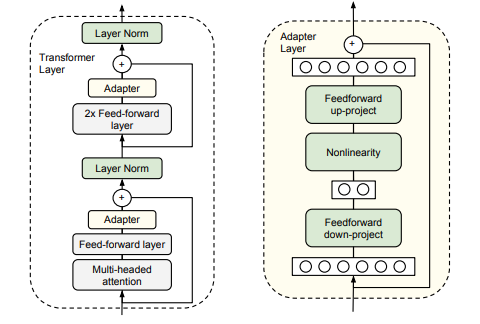

**Figure:** Bottleneck adapter architecture. The adapter first down-projects the hidden representation to a smaller bottleneck dimension, applies a nonlinear activation, and then up-projects it back to the original dimension. [*(Ref)*](https://arxiv.org/abs/1902.00751)

A typical bottleneck adapter follows:

$$
d \rightarrow r \rightarrow d
$$

where $r \ll d$.

The adapter transformation can be written as:

$$
h' = h + W_{\text{up}} f(W_{\text{down}}h)
$$

where:

- $W_{\text{down}}$ reduces the hidden dimension.
- $f$ is a nonlinear activation function.
- $W_{\text{up}}$ projects the representation back to the original dimension.
- The residual connection adds the adapter output back to the original hidden representation.

Only the adapter parameters are trained, while the pretrained Transformer parameters remain frozen. [*(Ref)*](https://arxiv.org/abs/1902.00751)

####  Task: MRPC Paraphrase Detection

The Microsoft Research Paraphrase Corpus (**MRPC**) is a sentence-pair classification task from the GLUE benchmark.

Given two sentences, the model predicts whether they express the **same meaning**:

- `1` → Paraphrase / Equivalent
- `0` → Not paraphrase / Not equivalent

Example:

> Sentence 1: The company reported a profit.  
> Sentence 2: The firm announced that it made money.

**Label:** Paraphrase

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

MODEL_ID = "bert-base-uncased"
TASK_NAME = "mnli"

TRAIN_SIZE = 20_000
VAL_SIZE = 2_000

dataset = load_dataset("nyu-mll/glue", TASK_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

train_data = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
val_data = dataset["validation_matched"].shuffle(seed=42).select(range(VAL_SIZE))

label_names = dataset["train"].features["label"].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

def tokenize_function(batch):
    return tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=128
    )

train_tokenized = train_data.map(
    tokenize_function,
    batched=True,
    remove_columns=["premise", "hypothesis", "idx"]
)

val_tokenized = val_data.map(
    tokenize_function,
    batched=True,
    remove_columns=["premise", "hypothesis", "idx"]
)

print("Task:", TASK_NAME)
print("Train examples:", len(train_tokenized))
print("Validation examples:", len(val_tokenized))
print("Train columns:", train_tokenized.column_names)
print("Validation columns:", val_tokenized.column_names)

#### A- BERT Fine Tuning

In [ ]:
from transformers import AutoModelForSequenceClassification

full_ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

for param in full_ft_model.parameters():
    param.requires_grad = True

full_ft_total = sum(
    p.numel()
    for p in full_ft_model.parameters()
)

full_ft_trainable = sum(
    p.numel()
    for p in full_ft_model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    f"{full_ft_total:,}"
)

print(
    "Trainable parameters:",
    f"{full_ft_trainable:,}"
)

print(
    "Trainable percentage:",
    f"{100 * full_ft_trainable / full_ft_total:.2f}%"
)

#### B- BERT Adapter Model

In [ ]:
from adapters import BertAdapterModel, BnConfig

adapter_config = BnConfig(
    mh_adapter=True,
    output_adapter=True,
    reduction_factor=16,
    non_linearity="relu"
)

model = BertAdapterModel.from_pretrained(
    MODEL_ID
)

model.add_adapter(
    TASK_NAME,
    config=adapter_config
)

model.add_classification_head(
    TASK_NAME,
    num_labels=3
)

model.train_adapter(
    TASK_NAME
)

model.set_active_adapters(
    TASK_NAME
)

model.active_head = TASK_NAME



print("Method: Bottleneck Adapter")

print(
    "Total parameters:",
    f"{adapter_total:,}"
)

print(
    "Trainable parameters:",
    f"{adapter_trainable:,}"
)

print(
    "Trainable percentage:",
    f"{adapter_percentage:.2f}%"
)

print(
    "Active adapters:",
    model.active_adapters
)

print(
    "Active head:",
    model.active_head
)

#### C- Training

In [ ]:
from transformers import (
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

adapter_args = TrainingArguments(
    output_dir="./mnli_adapter",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    learning_rate=1e-4,
    save_strategy="no",
    logging_steps=100,
    report_to="none",
)

adapter_trainer = Trainer(
    model=model,
    args=adapter_args,
    train_dataset=train_tokenized,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print("Training Bottleneck Adapter...")

adapter_train_result = adapter_trainer.train()


full_ft_args = TrainingArguments(
    output_dir="./mnli_full_ft",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    save_strategy="no",
    logging_steps=100,
    report_to="none",
)

full_ft_trainer = Trainer(
    model=full_ft_model,
    args=full_ft_args,
    train_dataset=train_tokenized,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print("\nTraining Full Fine-Tuning...")

full_ft_train_result = full_ft_trainer.train()


print("\nTraining finished.")

#### D- Evaluation

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def collate_fn(features):

    labels = torch.tensor(
        [feature["label"] for feature in features],
        dtype=torch.long
    )

    model_features = [
        {
            key: value
            for key, value in feature.items()
            if key != "label"
        }
        for feature in features
    ]

    batch = base_collator(model_features)
    batch["labels"] = labels

    return batch


val_loader = DataLoader(
    val_tokenized,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)


def evaluate_model(eval_model, is_adapter=False):

    eval_model.to(device)
    eval_model.eval()

    if is_adapter:
        eval_model.set_active_adapters(TASK_NAME)
        eval_model.active_head = TASK_NAME

    correct = 0
    total = 0

    with torch.no_grad():

        for batch in val_loader:

            labels = batch.pop("labels").to(device)

            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = eval_model(**batch)

            predictions = outputs.logits.argmax(dim=-1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


adapter_accuracy = evaluate_model(
    model,
    is_adapter=True
)

full_ft_accuracy = evaluate_model(
    full_ft_model,
    is_adapter=False
)


adapter_trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

full_ft_trainable = sum(
    p.numel()
    for p in full_ft_model.parameters()
    if p.requires_grad
)


results = pd.DataFrame({
    "Method": [
        "Bottleneck Adapter",
        "Full Fine-Tuning"
    ],
    "Trainable Parameters": [
        adapter_trainable,
        full_ft_trainable
    ],
    "Accuracy": [
        adapter_accuracy,
        full_ft_accuracy
    ]
})

display(results)


plt.figure(figsize=(9, 6))

plt.scatter(
    results["Trainable Parameters"],
    results["Accuracy"],
    s=250
)

for _, row in results.iterrows():

    plt.annotate(
        f"{row['Method']}\n"
        f"{row['Trainable Parameters'] / 1e6:.2f}M params\n"
        f"Accuracy = {row['Accuracy']:.3f}",
        (
            row["Trainable Parameters"],
            row["Accuracy"]
        ),
        xytext=(12, 10),
        textcoords="offset points"
    )

plt.xscale("log")
plt.xlabel("Trainable Parameters")
plt.ylabel("MNLI Validation Accuracy")
plt.title("Bottleneck Adapter vs Full Fine-Tuning")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 2- Low-Rank Adaptation (LoRA)

**Low-Rank Adaptation (LoRA)** is a Parameter-Efficient Fine-Tuning method introduced by **Hu et al. (2021)**. Instead of updating all pretrained model weights, LoRA freezes the original weights and learns a small low-rank update for selected weight matrices. [*(Ref)*](https://arxiv.org/abs/2106.09685)



During Full Fine-Tuning, a pretrained weight matrix $W$ is directly updated:

$$
W \rightarrow W'
$$

LoRA keeps the original matrix $W$ frozen and learns a separate update:

$$
W' = W + \Delta W
$$

Instead of learning the full update matrix $\Delta W$, LoRA represents it using two much smaller matrices:

$$
\Delta W = BA
$$

where:

$$
A \in \mathbb{R}^{r \times d}
$$

$$
B \in \mathbb{R}^{k \times r}
$$

and:

$$
r \ll \min(d,k)
$$

The value $r$ is called the **rank** of the LoRA adaptation. [*(Ref)*](https://arxiv.org/abs/2106.09685)



### Why Low Rank?

Suppose the original weight matrix is:

$$
W \in \mathbb{R}^{4096 \times 4096}
$$

A full update would require learning:

$$
4096 \times 4096
=
16,777,216
$$

parameters.

With LoRA rank:

$$
r=8
$$

we instead learn:

$$
A \in \mathbb{R}^{8 \times 4096}
$$

and:

$$
B \in \mathbb{R}^{4096 \times 8}
$$

requiring only:

$$
8(4096)+4096(8)
=
65,536
$$

parameters.

Therefore:

$$
65,536
\ll
16,777,216
$$

This is the main source of LoRA's parameter efficiency.



### LoRA Forward Pass

For an input $x$, the original layer computes:

$$
h = Wx
$$

With LoRA:

$$
h = Wx + BAx
$$

The pretrained matrix:

$$
W
$$

remains **frozen**, while only:

$$
A,\;B
$$

are optimized during training. [*(Ref)*](https://arxiv.org/abs/2106.09685)

A scaling factor is commonly applied:

$$
h
=
Wx
+
\frac{\alpha}{r}BAx
$$

where:

- $r$ = LoRA rank
- $\alpha$ = LoRA scaling parameter
- $A$ and $B$ = trainable low-rank matrices
- $W$ = frozen pretrained weight matrix



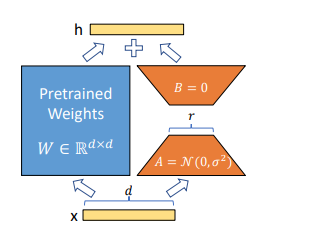


#### A- Qwen

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to("cuda")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_percentage = 100 * trainable_params / total_params

print("Before LoRA")
print("-" * 40)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_percentage:.4f}%")

#### B- LORA

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

MODEL_ID = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to("cuda")

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_percentage = 100 * trainable_params / total_params

print("LoRA")
print("-" * 40)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_percentage:.4f}%")

#### C- Training

In [ ]:
import torch
from transformers import DataCollatorForLanguageModeling, TrainingArguments, Trainer

SAVE_DIR = "./qwen_lora_mnli"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

def format_mnli(batch):
    texts = [f"Premise: {p}\nHypothesis: {h}\nRelationship: {label_names[y]}{tokenizer.eos_token}" for p, h, y in zip(batch["premise"], batch["hypothesis"], batch["label"])]
    return tokenizer(texts, truncation=True, max_length=128)

lora_train = train_data.map(format_mnli, batched=True, remove_columns=train_data.column_names)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    save_strategy="no",
    logging_steps=100,
    report_to="none",
    bf16=torch.cuda.is_available()
)

lora_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lora_train,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("Training LoRA...")
lora_train_result = lora_trainer.train()

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("LoRA training finished and model saved.")

tokenizer.padding_side = "left"
model.eval()

correct, total = 0, 0

for start in range(0, len(val_data), 32):
    batch = val_data[start:start + 32]
    prompts = [f"Premise: {p}\nHypothesis: {h}\nRelationship:" for p, h in zip(batch["premise"], batch["hypothesis"])]
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=4, do_sample=False)

    generated = outputs[:, inputs["input_ids"].shape[1]:]
    texts = tokenizer.batch_decode(generated, skip_special_tokens=True)

    for text, label in zip(texts, batch["label"]):
        prediction = next((i for i, name in enumerate(label_names) if name in text.lower().strip()), -1)
        correct += prediction == label
        total += 1

lora_accuracy = correct / total

print("\nLoRA Results")
print("-" * 40)
print(f"Validation examples: {total}")
print(f"Correct predictions: {correct}")
print(f"MNLI Accuracy:       {lora_accuracy:.4f}")
print(f"MNLI Accuracy:       {lora_accuracy * 100:.2f}%")

Prepared by:Lama